---
title: "Manufacturing failures: TabPFN 3 vs 3.5"
description: "Compare rare-failure detection on SECOM with wide and incomplete sensor data."
cookbookTags:
  - classification
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
---

A semiconductor production line produces many sensor readings, but only a small fraction of manufactured units fail testing. Here we use 590 sensor measurements to predict which examples will fail, even when some readings are missing. Ranking likely failures can help focus quality-control investigations on the units most worth checking.

## Setup

Install the dependencies in a fresh Python kernel. Compare TabPFN 3 and 3.5 with standard inference and high thinking effort. Timings include network and queue latency. Set `thinking_metric="average_precision"` so thinking optimizes the same metric shown in the results.

Authenticate using the [quickstart](https://docs.priorlabs.ai/cookbook/quickstart), or set `TABPFN_TOKEN` in your local environment before running the notebook.

In [ ]:
%pip install -q --upgrade tabpfn-client "pandas==2.3.3" "numpy==2.4.6" "scikit-learn==1.9.0" "matplotlib==3.11.1"

In [1]:
import time
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tabpfn_client import TabPFNClassifier
from tabpfn_client.api_models import ModelVersion
from tabpfn_client.models import ApiMode

VERSIONS = {"TabPFN 3": ModelVersion.V3, "TabPFN 3.5": ModelVersion.V3_5}
VARIANTS = [(name, thinking) for name in VERSIONS for thinking in (False, True)]
plt.rcParams.update({"figure.figsize": (7, 3.5), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 120})

def archive(url):
    return ZipFile(BytesIO(urlopen(url).read()))

The helpers below keep model settings and chart colors consistent across variants.

In [2]:
def model_for(cls, name, thinking=False, **kwargs):
    return cls.create_default_for_version(
        VERSIONS[name], n_estimators=4, random_state=42,
        api_mode=ApiMode.ASYNC if thinking else ApiMode.AUTO,
        thinking_effort="high" if thinking else None,
        thinking_metric="average_precision" if thinking else None, **kwargs,
    )

def performance_bars(results, metric, direction):
    colors = {"TabPFN 3": "#90a4ae", "TabPFN 3 + thinking high": "#5c6bc0",
              "TabPFN 3.5": "#80cbc4", "TabPFN 3.5 + thinking high": "#00897b",
              "XGBoost": "#bcaaa4"}
    values = results[metric].iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(values.index, values, color=[colors[name] for name in values.index])
    ax.set(xlabel=f"{metric} ({direction} is better)", ylabel="")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    low, high = values.min(), values.max()
    if low > 0 and high - low < 0.2 * high:
        padding = max((high - low) * 0.3, high * 0.01, 0.001)
        ax.set_xlim(max(0, low - padding), high + 2 * padding)
        ax.set_title("Zoomed axis (does not start at zero)", fontsize=9)
    else:
        ax.set_xlim(0, high * 1.22)
    fig.tight_layout()
    plt.show()


## Data and split

[UCI SECOM](https://archive.ics.uci.edu/dataset/179/secom) has 1,567 manufacturing examples and 590 sensor columns. Label `+1` means failure. Hold out the latest 20% by timestamp to mimic predicting future production. Timestamps define the split and are excluded from features; no resampling or manual imputation.

In [3]:
from sklearn.metrics import log_loss, average_precision_score
with archive("https://archive.ics.uci.edu/static/public/179/secom.zip") as z:
    X = np.loadtxt(z.open("secom.data"))
    labels = pd.read_csv(z.open("secom_labels.data"), sep=r"\s+", header=None)
y = (labels[0].to_numpy() == 1).astype(int)
order = np.argsort(pd.to_datetime(labels[1], dayfirst=True).to_numpy(), kind="stable")
cut = int(0.8 * len(y))
train, test = order[:cut], order[cut:]
X_train, X_test, y_train, y_test = X[train], X[test], y[train], y[test]
assert X.shape == (1567, 590) and len(np.unique(y_test)) == 2
print(f"Train / test: {len(train)} / {len(test)}; missing: {np.isnan(X).mean():.1%}")
print(f"Failures: train {y_train.sum()} ({y_train.mean():.1%}), test {y_test.sum()} ({y_test.mean():.1%})")

Train / test: 1253 / 314; missing: 4.5%
Failures: train 87 (6.9%), test 17 (5.4%)


## Compare

All four variants receive the same incomplete sensor measurements. **Average precision** measures the ranking of rare failures; higher is better. Thinking explicitly optimizes average precision, which is also the only performance metric displayed.

In [4]:
rows, predictions = [], {}
for name, thinking in VARIANTS:
    label = name + (" + thinking high" if thinking else "")
    start = time.perf_counter()
    model = model_for(TabPFNClassifier, name, thinking)
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    predictions[label] = p
    rows.append({"Model": label, "Average precision": average_precision_score(y_test, p),
                 "Log-loss": log_loss(y_test, p),
                 "Seconds": time.perf_counter() - start})
    print(f"Finished {label}")
all_results = pd.DataFrame(rows).set_index("Model")

Train set already exists, skipping upload.


Test set already exists, skipping upload.


Finished TabPFN 3


Train set already exists, skipping upload.


Test set already exists, skipping upload.


...

Test set already exists, skipping upload.


Train set already exists, skipping upload.


Finished TabPFN 3.5


Test set already exists, skipping upload.


Finished TabPFN 3.5 + thinking high


## Results

TabPFN 3.5 raises average precision from 0.0618 to 0.0809 compared with v3. Thinking explicitly optimized for average precision improves both versions further, to 0.0777 and 0.0859 respectively. The newer model with thinking ranks failures best, although the test period contains only 17 failures.

In [5]:
display(all_results[["Average precision"]].round(4))

,Average precision
Model,
TabPFN 3,0.0618
TabPFN 3 + thinking high,0.0777
TabPFN 3.5,0.0809
TabPFN 3.5 + thinking high,0.0859


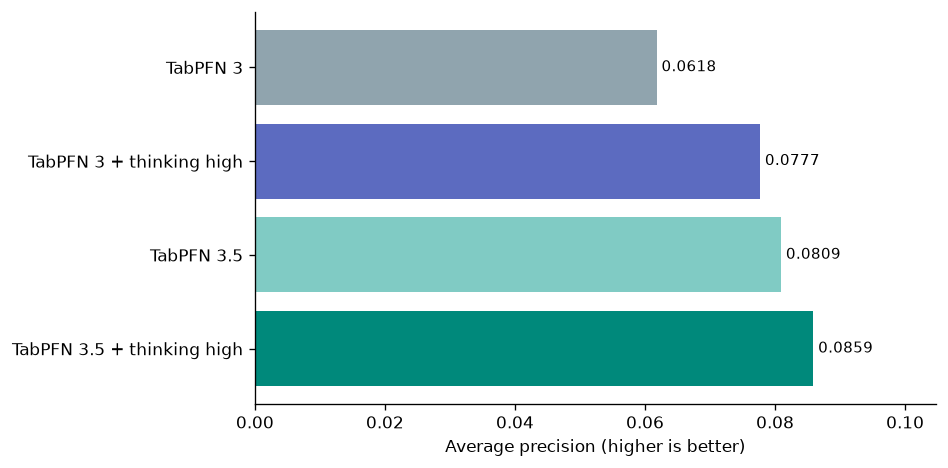

In [6]:
performance_bars(all_results, "Average precision", "higher")

### What to take away

Both the newer model and thinking improve failure ranking on these held-out production examples. Average precision remains modest, so the result illustrates progress on a difficult rare-event task rather than a production-ready detector.